In [92]:
from common.paths import get_data_bench_dpath, get_data_raw_dpath
from common.logger import JUPYTER_LOGGER as logger

import catboost as cb
import xgboost as xgb
import lightgbm as lgb

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, average_precision_score
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import optuna

from matplotlib import pyplot as plt
import seaborn as sns

from typing import *

In [93]:
train_data_fpath = get_data_raw_dpath() / 'merged_features_with_judge_scores.csv'
val_data_fpath = get_data_bench_dpath() / 'bench_processed_judged_mapped.csv'

train_df = pd.read_csv(train_data_fpath)
val_df = pd.read_csv(val_data_fpath).drop(["comment"], axis=1)

logger.info(f'Train shape (raw): {train_df.shape}')
logger.info(f'Validation shape (raw): {val_df.shape}')
val_df.head()

C:\Users\User\AppData\Local\Temp\ipykernel_4328\658114013.py:4: DtypeWarning: Columns (0: judge_score) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(train_data_fpath)
2026-04-06 22:29:48,872 - jupyter-notebooks - INFO - [JUPYTER 📓] Train shape (raw): (2958, 1622)
2026-04-06 22:29:48,872 - jupyter-notebooks - INFO - [JUPYTER 📓] Validation shape (raw): (1044, 1622)


,sample_id,model_answer,is_hallucination,correct_answer,query,temperature,hallucination_score,mean_log_prob,min_log_prob,max_log_prob,...,moe_std_top_prob_mean,moe_std_top_prob_std,moe_mean_entropy_mean,moe_mean_entropy_std,moe_std_entropy_mean,moe_std_entropy_std,moe_active_ratio_mean,moe_active_ratio_std,judge_prompt,judge_score
0,0,Оскар Густав Рейландер был удостоен медали на ...,1,За выставленные фотографии,За что Оскар Густав Рейландер был удостоен мед...,1.049065,57.692308,-15.9375,-25.625,-0.000228,...,0.178539,0.039309,2.873901,0.439506,0.658988,0.149201,0.337054,0.100173,"\nТы — судья, оценивающий точность ответа моде...",True
1,1,Рэпер King Von был убит 6 ноября 2020 года в р...,0,2020,В каком году рэпер King Von был убит?,1.049065,100.000000,-15.3125,-24.625,-8.625000,...,0.262459,0.052259,2.225478,0.458625,1.014426,0.247416,0.245536,0.038012,"\nТы — судья, оценивающий точность ответа моде...",False
2,2,На реализацию программы защиты свидетелей в Ро...,1,1318,Сколько миллионов рублей было выделено на реал...,1.049065,50.000000,-13.7500,-19.625,-3.593750,...,0.260172,0.063890,2.361040,0.479723,1.017916,0.300025,0.243304,0.053385,"\nТы — судья, оценивающий точность ответа моде...",True
3,3,Фильм «Евангелион 2.22: Ты (не) пройдёшь» был ...,1,Reanimedia,Какая компания лицензировала на русском языке ...,1.049065,0.000000,-15.8125,-27.750,-0.000085,...,0.262319,0.088833,2.447545,0.518659,1.041071,0.368324,0.285714,0.067187,"\nТы — судья, оценивающий точность ответа моде...",True
4,4,В 2000 году британский историк Дэвид Ирвин (Da...,1,Джоэла Хейворда,Кто из британских ревизионистов в 2000 году пр...,1.049065,46.666667,-17.0000,-28.625,-0.000668,...,0.205291,0.023385,2.700101,0.265808,0.769720,0.096830,0.279018,0.085756,"\nТы — судья, оценивающий точность ответа моде...",True


In [94]:
train_df.head()

,sample_id,query,correct_answer,model_answer,temperature,hallucination_score,is_hallucination,mean_log_prob,min_log_prob,max_log_prob,...,moe_std_top_prob_mean,moe_std_top_prob_std,moe_mean_entropy_mean,moe_mean_entropy_std,moe_std_entropy_mean,moe_std_entropy_std,moe_active_ratio_mean,moe_active_ratio_std,judge_prompt,judge_score
0,0,"ЭТОГО православного святого иногда называют ""м...",Федор УШАКОВ,Святого Николая Чудотворца иногда называют «мо...,1.049065,41.666667,1,-2.184582,-16.949598,-0.000303,...,0.028273,0.019163,0.029646,0.015739,0.073697,0.044748,0.5,0.0,"\r\nТы — судья, оценивающий точность ответа мо...",True
1,2,"Именно ему мы так верили, ""как, может быть, не...",Жириновскому,Эта фраза — цитата из романа Михаила Булгакова...,1.049065,50.000000,1,-2.475740,-16.976189,-0.000039,...,0.038252,0.016981,0.041029,0.022800,0.096321,0.038822,0.5,0.0,"\r\nТы — судья, оценивающий точность ответа мо...",True
2,3,В этой знаменитой российской иерархии было 14 ...,"В ""Табели о рангах""","Вероятно, вы имеете в виду «Иерархию» — знамен...",1.049065,47.368421,1,-0.628662,-3.925333,-0.000001,...,0.068875,0.014358,0.075975,0.026233,0.160563,0.027780,0.5,0.0,"\r\nТы — судья, оценивающий точность ответа мо...",True
3,4,"Согласно Большому толковому словарю, это — ""не...","Стопка. Зачет: Стопарь, стопарик",Это слово - *штоф*. \r\n\r\nШтоф — это небольш...,1.049065,40.625000,1,-2.889339,-17.423979,-0.000020,...,0.047839,0.027707,0.053740,0.039204,0.116196,0.058728,0.5,0.0,"\r\nТы — судья, оценивающий точность ответа мо...",True
4,5,Купюру в 50 австралийских долларов украшает по...,Машинка для стрижки овец,"Ответ на загадку: **банкнота**, **портрет** и ...",1.049065,33.333333,1,-3.065416,-17.067001,-0.000071,...,0.026798,0.025066,0.039801,0.033253,0.075060,0.057870,0.5,0.0,"\r\nТы — судья, оценивающий точность ответа мо...",True


In [95]:
# add statistic text features

import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import rapidfuzz

stop_words = set(stopwords.words('russian'))

def count_tokens(text: str) -> int:
    return len(word_tokenize(text))

def count_stopwords(text: str) -> int:
    tokens = word_tokenize(text)
    return sum(1 for token in tokens if token.lower() in stop_words)

def count_digits(text: str) -> int:
    return len(re.findall(r'\d', text))

def count_punctuation(text: str) -> int:
    return len(re.findall(r'[^\w\s]', text))

def count_fuzz_partial_ratio(query: str, answer: str) -> float:
    return rapidfuzz.fuzz.partial_ratio(query, answer)


def add_text_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["query_token_count"] = df["query"].apply(count_tokens)
    df["answer_token_count"] = df["model_answer"].apply(count_tokens)
    df["query_stopword_count"] = df["query"].apply(count_stopwords)
    df["answer_stopword_count"] = df["model_answer"].apply(count_stopwords)
    df["query_digit_count"] = df["query"].apply(count_digits)
    df["answer_digit_count"] = df["model_answer"].apply(count_digits)
    df["query_punctuation_count"] = df["query"].apply(count_punctuation)
    df["answer_punctuation_count"] = df["model_answer"].apply(count_punctuation)
    df["query_answer_token_diff"] = df["query_token_count"] - df["answer_token_count"]
    df["query_answer_fuzz_partial_ratio"] = df.apply(
        lambda row: count_fuzz_partial_ratio(row["query"], row["model_answer"]),
        axis=1
    )
    return df

train_df = add_text_features(train_df)
val_df = add_text_features(val_df)

In [96]:
# tfidf
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=1000)
train_tfidf = tfidf_vectorizer.fit_transform(train_df["model_answer"])
val_tfidf = tfidf_vectorizer.transform(val_df["model_answer"])

tfidf_feature_names = [f"tfidf_{i}" for i in range(train_tfidf.shape[1])]

train_tfidf_df = pd.DataFrame(train_tfidf.toarray(), columns=tfidf_feature_names)
val_tfidf_df = pd.DataFrame(val_tfidf.toarray(), columns=tfidf_feature_names)

train_df = pd.concat([train_df.reset_index(drop=True), train_tfidf_df], axis=1)
val_df = pd.concat([val_df.reset_index(drop=True), val_tfidf_df], axis=1)

In [97]:
features_cols_map = {
    (0, 11): "uncertainty",
    (12, 35): "internal_scalars",
    (36, 1571): "probe_vec",
    (1572, 1595): "attention_entropy",
    (1596, 1602): "entropy_drops",
    (1603, 1612): "moe_routing",
    (1613, 1622): "text_features",
    (1623, 2622): "tfidf",
}

uncertainty_map = [
    "mean_log_prob",        # 0
    "min_log_prob",         # 1
    "max_log_prob",         # 2
    "std_log_prob",         # 3
    "mean_entropy",         # 4
    "min_entropy",          # 5
    "max_entropy",          # 6
    "std_entropy",          # 7
    "n_answer_tokens",      # 8
    "first_token_log_prob", # 9
    "mean_top1_prob",       # 10
    "mean_top5_prob_sum",   # 11
]

PROBE_LAYERS = [0, 4, 8, 12, 16, 20, 24, 25]

internal_scalars_map = [
    f"layer_{l}_{s}"
    for l in PROBE_LAYERS
    for s in ["prompt_last_token_norm", "answer_hidden_norm_mean", "logit_lens_entropy"]
]
# layer_0_prompt_last_token_norm, layer_0_answer_hidden_norm_mean, layer_0_logit_lens_entropy,
# layer_4_prompt_last_token_norm, ...

probe_vec_map = [f"probe_vec_{i}" for i in range(1536)]  # 36–1571

attention_entropy_map = [
    f"attn_layer_{l}_{s}"
    for l in PROBE_LAYERS
    for s in ["entropy_mean", "entropy_max", "entropy_std"]
]
# attn_layer_0_entropy_mean, attn_layer_0_entropy_max, attn_layer_0_entropy_std,
# attn_layer_4_entropy_mean, ...

entropy_drops_map = [
    f"entropy_drop_{PROBE_LAYERS[i]}_to_{PROBE_LAYERS[i+1]}"
    for i in range(len(PROBE_LAYERS) - 1)
]
# entropy_drop_0_to_4, entropy_drop_4_to_8, ..., entropy_drop_24_to_25

moe_routing_map = [
    "moe_mean_top_prob_mean",
    "moe_mean_top_prob_std",
    "moe_std_top_prob_mean",
    "moe_std_top_prob_std",
    "moe_mean_entropy_mean",
    "moe_mean_entropy_std",
    "moe_std_entropy_mean",
    "moe_std_entropy_std",
    "moe_active_ratio_mean",
    "moe_active_ratio_std",
]

text_features_map = [
    "query_token_count",
    "answer_token_count",
    "query_stopword_count",
    "answer_stopword_count",
    "query_digit_count",
    "answer_digit_count",
    "query_punctuation_count",
    "answer_punctuation_count",
    "query_answer_token_diff",
    "query_answer_fuzz_partial_ratio",
]

# Полный маппинг feature_0..feature_1612 → имя
all_feature_names = (
    uncertainty_map
    + internal_scalars_map
    + probe_vec_map
    + attention_entropy_map
    + entropy_drops_map
    + moe_routing_map
    + text_features_map
    + tfidf_feature_names
)

feature_groups: dict[str, list[str]] = {
    "uncertainty": uncertainty_map,
    "internal_scalars": internal_scalars_map,
    "probe_vec": probe_vec_map,
    "attention_entropy": attention_entropy_map,
    "entropy_drops": entropy_drops_map,
    "moe_routing": moe_routing_map,
    "text_features": text_features_map,
    "tfidf": tfidf_feature_names,
}


def rename_feature_columns(data_df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    feature_cols = [col for col in data_df.columns if col.startswith("feature_")]
    if not feature_cols:
        logger.info(f"[{dataset_name}] feature_* columns not found, skip rename.")
        return data_df

    if len(feature_cols) != len(all_feature_names):
        raise ValueError(
            f"[{dataset_name}] invalid number of feature columns: "
            f"{len(feature_cols)} != {len(all_feature_names)}"
        )

    rename_map = dict(zip(feature_cols, all_feature_names))
    renamed_df = data_df.rename(columns=rename_map)
    start_idx = renamed_df.columns.get_loc(all_feature_names[0])
    end_idx = renamed_df.columns.get_loc(all_feature_names[-1])
    logger.info(f"[{dataset_name}] feature columns index range: {start_idx}-{end_idx}")
    return renamed_df


train_df = rename_feature_columns(train_df, "train")
val_df = rename_feature_columns(val_df, "validation")

train_df.head()

2026-04-06 22:29:58,003 - jupyter-notebooks - INFO - [JUPYTER 📓] [train] feature_* columns not found, skip rename.
2026-04-06 22:29:58,010 - jupyter-notebooks - INFO - [JUPYTER 📓] [validation] feature_* columns not found, skip rename.


,sample_id,query,correct_answer,model_answer,temperature,hallucination_score,is_hallucination,mean_log_prob,min_log_prob,max_log_prob,...,tfidf_990,tfidf_991,tfidf_992,tfidf_993,tfidf_994,tfidf_995,tfidf_996,tfidf_997,tfidf_998,tfidf_999
0,0,"ЭТОГО православного святого иногда называют ""м...",Федор УШАКОВ,Святого Николая Чудотворца иногда называют «мо...,1.049065,41.666667,1,-2.184582,-16.949598,-0.000303,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,"Именно ему мы так верили, ""как, может быть, не...",Жириновскому,Эта фраза — цитата из романа Михаила Булгакова...,1.049065,50.000000,1,-2.475740,-16.976189,-0.000039,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,В этой знаменитой российской иерархии было 14 ...,"В ""Табели о рангах""","Вероятно, вы имеете в виду «Иерархию» — знамен...",1.049065,47.368421,1,-0.628662,-3.925333,-0.000001,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,"Согласно Большому толковому словарю, это — ""не...","Стопка. Зачет: Стопарь, стопарик",Это слово - *штоф*. \r\n\r\nШтоф — это небольш...,1.049065,40.625000,1,-2.889339,-17.423979,-0.000020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,Купюру в 50 австралийских долларов украшает по...,Машинка для стрижки овец,"Ответ на загадку: **банкнота**, **портрет** и ...",1.049065,33.333333,1,-3.065416,-17.067001,-0.000071,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [98]:
# cfg

# preprocessing
pca_n_components: Optional[int] = 128
tfidf_n_components: Optional[int] = 64
scaling: bool = False
under_sampling: bool = True
oversampling: bool = False
uncertainty: bool = True
internal_scalars: bool = False
probe_vec: bool = False
attention_entropy: bool = False
entropy_drops: bool = False
moe_routing: bool = False
text_features: bool = True
tfidf_features: bool = True
bad_features: list[str] = [
    ]
bad_features.extend(
    [f"layer_{i}_prompt_last_token_norm" for i in PROBE_LAYERS] +
    [f"layer_{i}_answer_hidden_norm_mean" for i in PROBE_LAYERS] +
    ["min_entropy", "std_entropy"]
)
feature_plot_batch_size: int = 24

if bad_features:
    train_cols_to_drop = [column_name for column_name in bad_features if column_name in train_df.columns]
    val_cols_to_drop = [column_name for column_name in bad_features if column_name in val_df.columns]

    train_df = train_df.drop(columns=train_cols_to_drop)
    val_df = val_df.drop(columns=val_cols_to_drop)

    logger.info(f"Dropped bad features from train: {train_cols_to_drop}")
    logger.info(f"Dropped bad features from validation: {val_cols_to_drop}")

# fixed class weight из исходного train-распределения (до оверсемплинга)
fixed_pos_weight: float | None = None

# optuna objectives
X_train_base, y_train_base, X_val, y_val, X_train, y_train = None, None, None, None, None, None

FEATURE_GROUP_FLAGS: dict[str, bool] = {
    "uncertainty": uncertainty,
    "internal_scalars": internal_scalars,
    "probe_vec": probe_vec,
    "attention_entropy": attention_entropy,
    "entropy_drops": entropy_drops,
    "moe_routing": moe_routing,
    "text_features": text_features,
    "tfidf": tfidf_features,
}


def get_selected_feature_names(available_features: set[str]) -> list[str]:
    groups_to_use = [group_name for group_name, enabled in FEATURE_GROUP_FLAGS.items() if enabled]
    if not groups_to_use:
        raise ValueError("At least one feature-group flag must be True")

    selected_names: list[str] = []
    for group_name in groups_to_use:
        if group_name not in feature_groups:
            raise ValueError(f"Unknown feature group: {group_name}")
        selected_names.extend([name for name in feature_groups[group_name] if name in available_features])

    if not selected_names:
        raise ValueError("No selected features were found in both train and validation datasets")
    return selected_names


def plot_feature_distributions(
    train_data_df: pd.DataFrame,
    val_data_df: pd.DataFrame,
    feature_names: list[str],
    batch_size: int = 24,
) -> None:
    train_plot_df = train_data_df[feature_names].copy()
    train_plot_df["split"] = "train"

    val_plot_df = val_data_df[feature_names].copy()
    val_plot_df["split"] = "validation"

    combined_plot_df = pd.concat([train_plot_df, val_plot_df], axis=0, ignore_index=True)

    for batch_start in range(0, len(feature_names), batch_size):
        batch_features = feature_names[batch_start: batch_start + batch_size]
        n_cols = 4
        n_rows = int(np.ceil(len(batch_features) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, max(4 * n_rows, 5)))
        axes = np.array(axes).reshape(-1)

        for ax_idx, feature_name in enumerate(batch_features):
            ax = axes[ax_idx]
            sns.histplot(
                data=combined_plot_df,
                x=feature_name,
                hue="split",
                bins=30,
                kde=True,
                stat="density",
                common_norm=False,
                ax=ax,
            )
            ax.set_title(feature_name)

        for ax in axes[len(batch_features):]:
            ax.axis("off")

        fig.suptitle(
            f"Feature distributions train vs validation [{batch_start + 1}-{batch_start + len(batch_features)}]",
            y=1.02,
        )
        plt.tight_layout()
        plt.show()

2026-04-06 22:29:59,601 - jupyter-notebooks - INFO - [JUPYTER 📓] Dropped bad features from train: ['layer_0_prompt_last_token_norm', 'layer_4_prompt_last_token_norm', 'layer_8_prompt_last_token_norm', 'layer_12_prompt_last_token_norm', 'layer_16_prompt_last_token_norm', 'layer_20_prompt_last_token_norm', 'layer_24_prompt_last_token_norm', 'layer_25_prompt_last_token_norm', 'layer_0_answer_hidden_norm_mean', 'layer_4_answer_hidden_norm_mean', 'layer_8_answer_hidden_norm_mean', 'layer_12_answer_hidden_norm_mean', 'layer_16_answer_hidden_norm_mean', 'layer_20_answer_hidden_norm_mean', 'layer_24_answer_hidden_norm_mean', 'layer_25_answer_hidden_norm_mean', 'min_entropy', 'std_entropy']
2026-04-06 22:29:59,603 - jupyter-notebooks - INFO - [JUPYTER 📓] Dropped bad features from validation: ['layer_0_prompt_last_token_norm', 'layer_4_prompt_last_token_norm', 'layer_8_prompt_last_token_norm', 'layer_12_prompt_last_token_norm', 'layer_16_prompt_last_token_norm', 'layer_20_prompt_last_token_norm'

2026-04-06 22:30:02,587 - jupyter-notebooks - INFO - [JUPYTER 📓] Selected feature groups: ['uncertainty', 'text_features', 'tfidf']
2026-04-06 22:30:02,590 - jupyter-notebooks - INFO - [JUPYTER 📓] Selected features count before PCA: 1020
C:\Users\User\AppData\Local\Temp\ipykernel_4328\3917434958.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_processed_hist.index, y=df_processed_hist.values, palette='viridis')


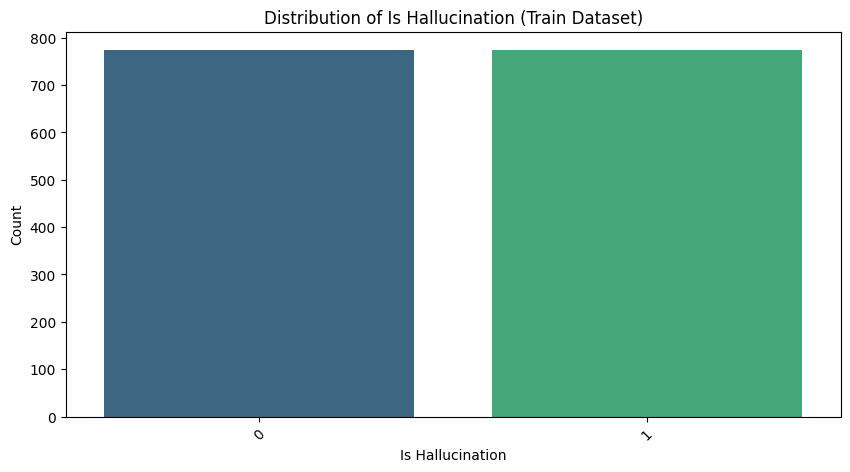

In [99]:
# Preprocessing

target_col = "is_hallucination"
if target_col not in train_df.columns or target_col not in val_df.columns:
    raise ValueError(f"'{target_col}' must exist in both train and validation datasets")

for current_df in (train_df, val_df):
    num_cols = current_df.select_dtypes(include=[np.number]).columns.difference(["sample_id"])
    for col in num_cols:
        current_df[col] = pd.to_numeric(current_df[col], errors='coerce')

common_cols = set(train_df.columns).intersection(set(val_df.columns))
selected_feature_names = get_selected_feature_names(common_cols)
selected_group_names = [
    group_name
    for group_name, enabled in FEATURE_GROUP_FLAGS.items()
    if enabled
]
logger.info(f"Selected feature groups: {selected_group_names}")
logger.info(f"Selected features count before PCA: {len(selected_feature_names)}")

preprocessed_train_df = train_df.copy()
preprocessed_val_df = val_df.copy()


def _replace_selected_features(
    selected_names: list[str],
    features_to_remove: list[str],
    features_to_add: list[str],
) -> list[str]:
    base_names = [name for name in selected_names if name not in set(features_to_remove)]
    return base_names + features_to_add

selected_probe_vec = [feature_name for feature_name in probe_vec_map if feature_name in selected_feature_names]
if pca_n_components is not None and selected_probe_vec:
    pca_components = min(pca_n_components, len(selected_probe_vec), len(preprocessed_train_df))
    pca = PCA(n_components=pca_components, random_state=42)

    train_probe_vec = preprocessed_train_df[selected_probe_vec].values
    val_probe_vec = preprocessed_val_df[selected_probe_vec].values

    train_pca_features = pca.fit_transform(train_probe_vec)
    val_pca_features = pca.transform(val_probe_vec)
    pca_feature_names = [f"pca_probe_vec_{i}" for i in range(pca_components)]

    preprocessed_train_df = preprocessed_train_df.drop(columns=selected_probe_vec)
    preprocessed_val_df = preprocessed_val_df.drop(columns=selected_probe_vec)
    preprocessed_train_df[pca_feature_names] = train_pca_features
    preprocessed_val_df[pca_feature_names] = val_pca_features
    selected_feature_names = _replace_selected_features(
        selected_names=selected_feature_names,
        features_to_remove=selected_probe_vec,
        features_to_add=pca_feature_names,
    )

if tfidf_n_components is not None and tfidf_features:
    tfidf_cols = [feature_name for feature_name in tfidf_feature_names if feature_name in selected_feature_names]
    if tfidf_cols:
        pca_components = min(tfidf_n_components, len(tfidf_cols), len(preprocessed_train_df))
        pca_tfidf = PCA(n_components=pca_components, random_state=42)

        train_tfidf_features = preprocessed_train_df[tfidf_cols].values
        val_tfidf_features = preprocessed_val_df[tfidf_cols].values

        train_tfidf_pca = pca_tfidf.fit_transform(train_tfidf_features)
        val_tfidf_pca = pca_tfidf.transform(val_tfidf_features)
        tfidf_pca_feature_names = [f"pca_{name}" for name in tfidf_cols[:pca_components]]

        preprocessed_train_df = preprocessed_train_df.drop(columns=tfidf_cols)
        preprocessed_val_df = preprocessed_val_df.drop(columns=tfidf_cols)
        preprocessed_train_df[tfidf_pca_feature_names] = train_tfidf_pca
        preprocessed_val_df[tfidf_pca_feature_names] = val_tfidf_pca
        selected_feature_names = _replace_selected_features(
            selected_names=selected_feature_names,
            features_to_remove=tfidf_cols,
            features_to_add=tfidf_pca_feature_names,
        )

missing_train_features = [name for name in selected_feature_names if name not in preprocessed_train_df.columns]
missing_val_features = [name for name in selected_feature_names if name not in preprocessed_val_df.columns]
if missing_train_features or missing_val_features:
    raise ValueError(
        "Selected features are missing after preprocessing. "
        f"Missing in train: {missing_train_features[:10]}, "
        f"missing in validation: {missing_val_features[:10]}"
    )

if scaling:
    from sklearn.preprocessing import StandardScaler

    scaler = StandardScaler()
    preprocessed_train_df[selected_feature_names] = scaler.fit_transform(preprocessed_train_df[selected_feature_names])
    preprocessed_val_df[selected_feature_names] = scaler.transform(preprocessed_val_df[selected_feature_names])


# shuffle
preprocessed_train_df = preprocessed_train_df.sample(frac=1.0, random_state=42).reset_index(drop=True)

X_train_base = preprocessed_train_df[selected_feature_names].copy()
y_train_base = preprocessed_train_df[target_col].copy()

if under_sampling:
    from imblearn.under_sampling import RandomUnderSampler

    rus = RandomUnderSampler(random_state=42)
    X_resampled, y_resampled = rus.fit_resample(X_train_base, y_train_base)
    X_train_base = pd.DataFrame(X_resampled, columns=selected_feature_names)
    y_train_base = pd.Series(y_resampled, name=target_col)

X_val = preprocessed_val_df[selected_feature_names].copy()
y_val = preprocessed_val_df[target_col].copy()

df_processed_hist = y_train_base.value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(x=df_processed_hist.index, y=df_processed_hist.values, palette='viridis')
plt.title('Distribution of Is Hallucination (Train Dataset)')
plt.xlabel('Is Hallucination')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_4328\3586615686.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_val_hist.index, y=df_val_hist.values, palette='magma')


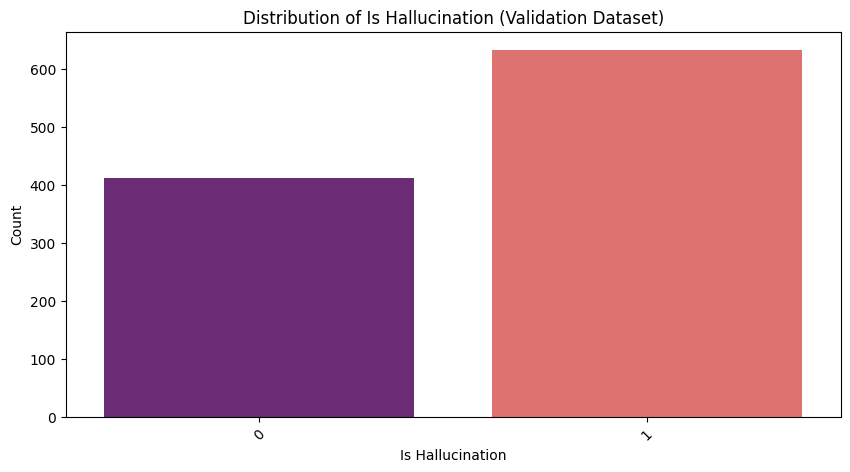

In [100]:
df_val_hist = y_val.value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(x=df_val_hist.index, y=df_val_hist.values, palette='magma')
plt.title('Distribution of Is Hallucination (Validation Dataset)')
plt.xlabel('Is Hallucination')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

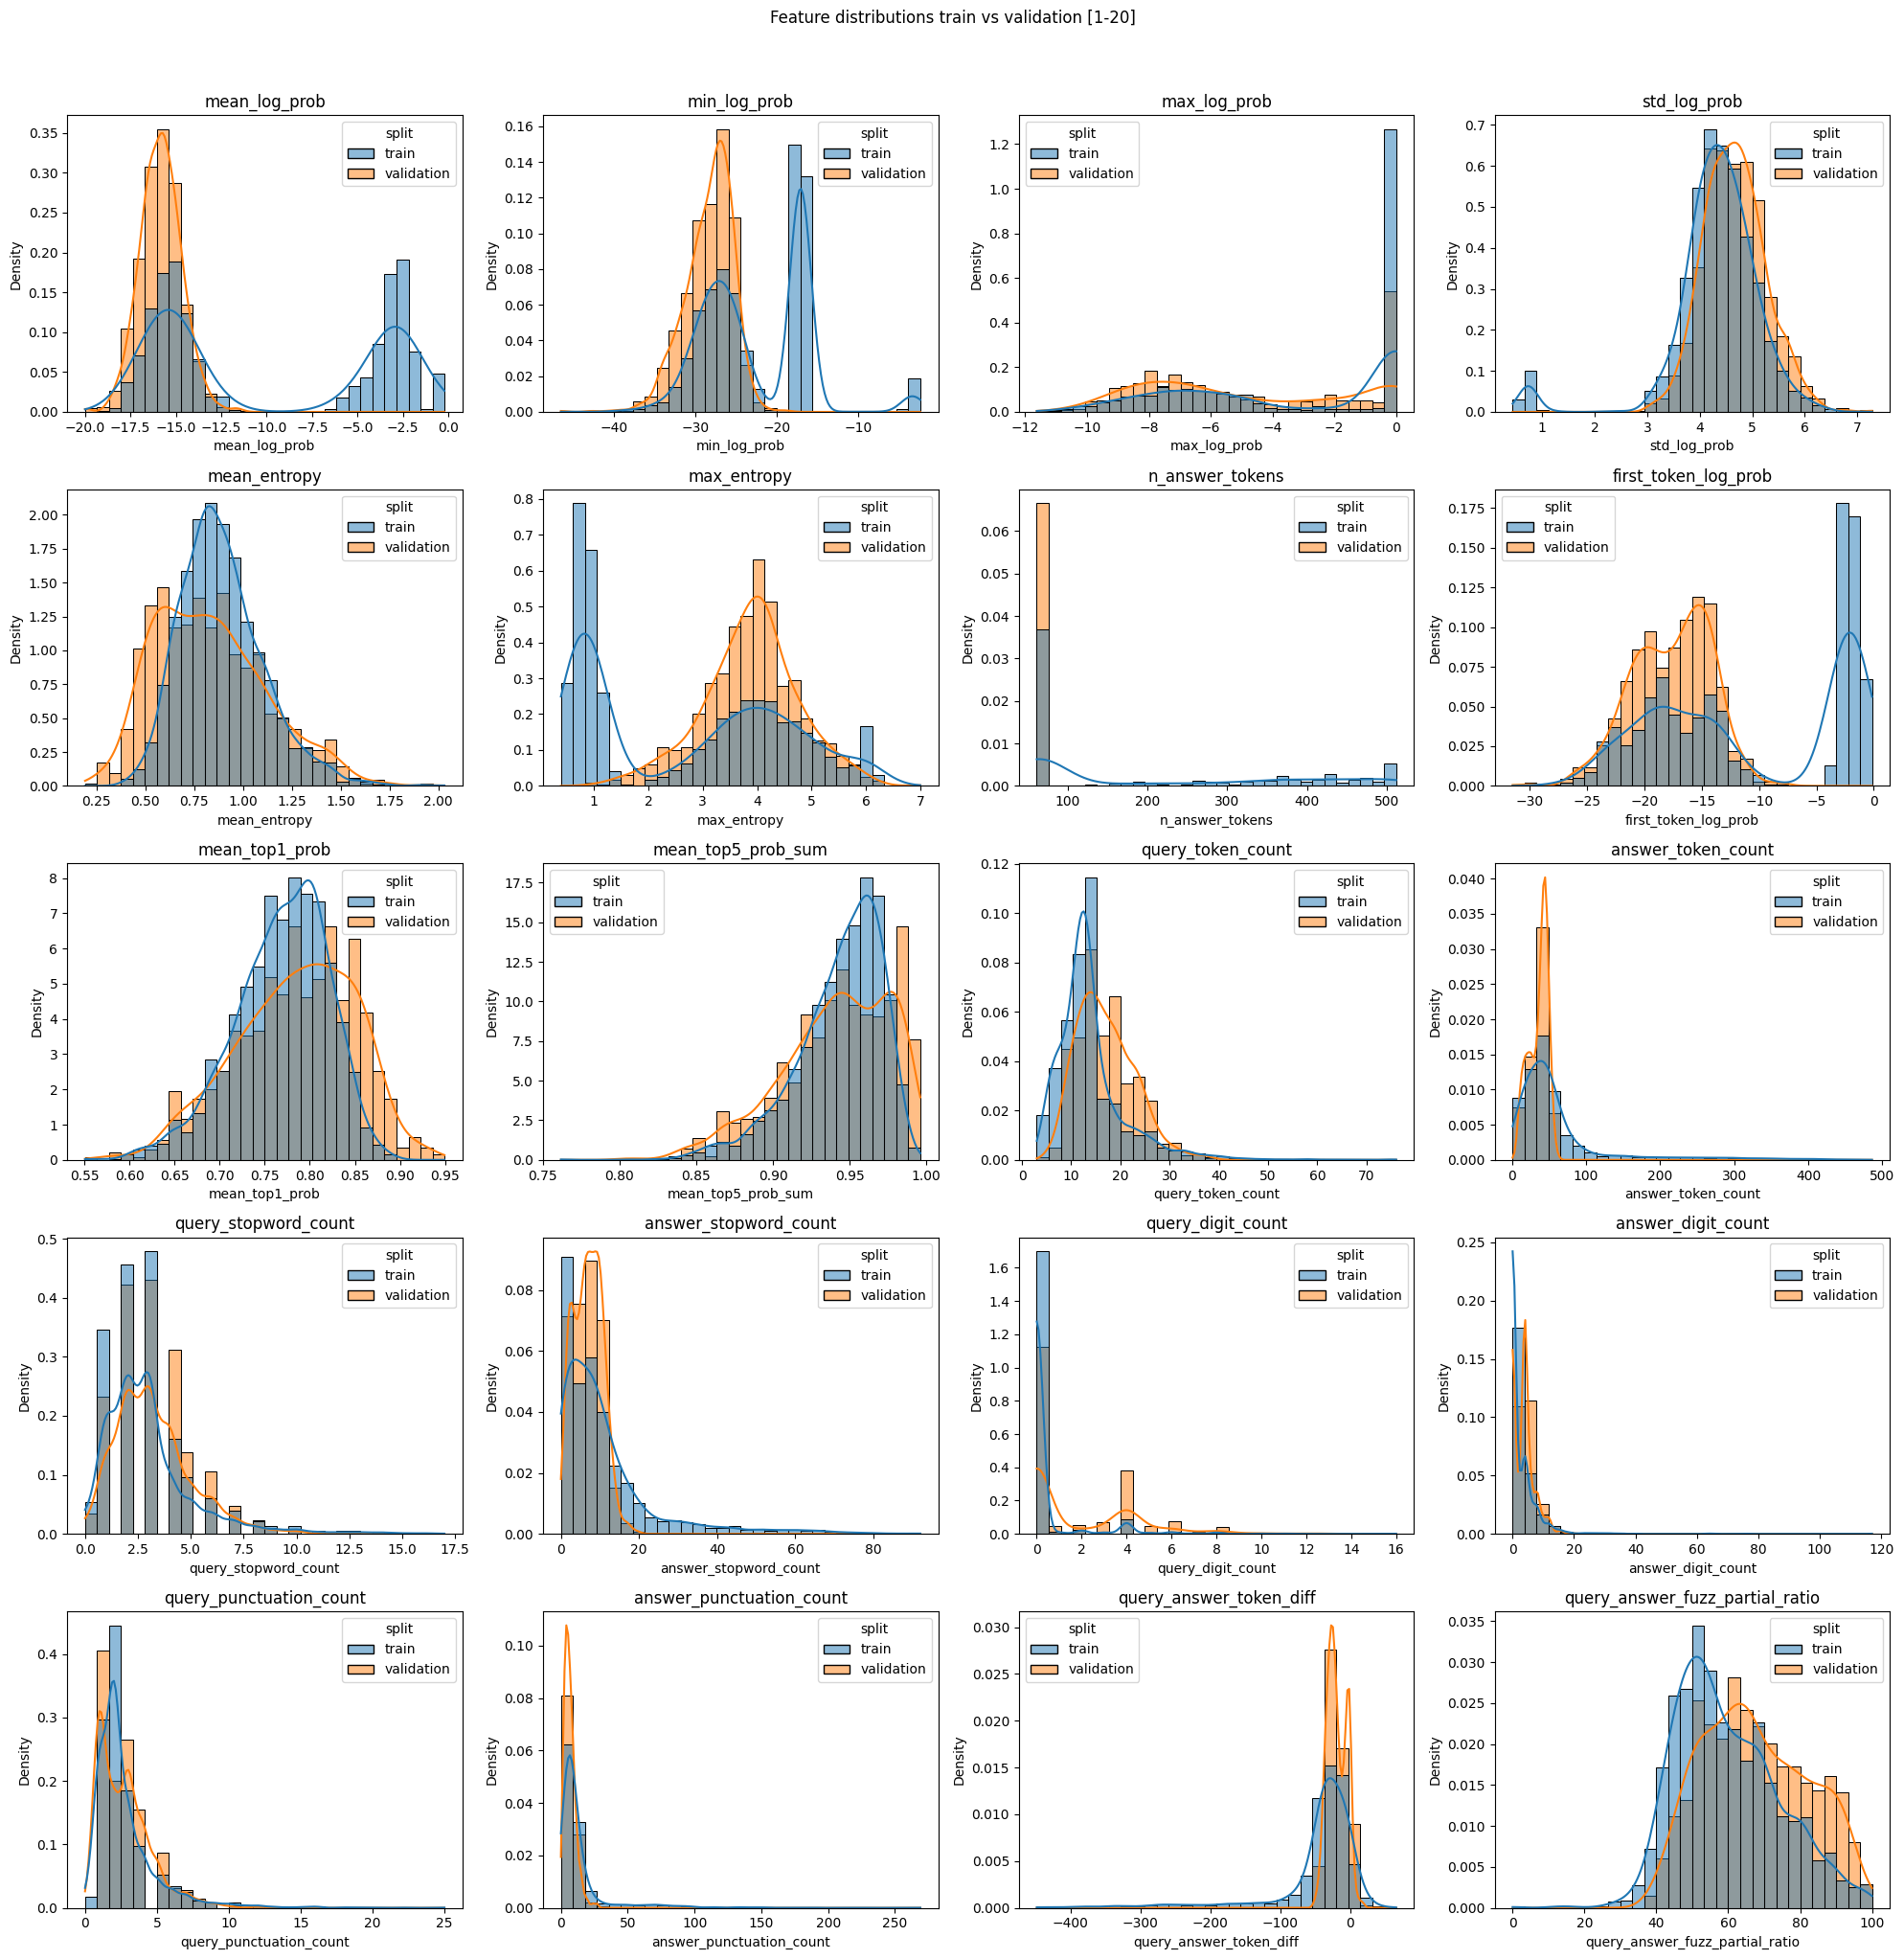

In [73]:
plot_feature_distributions(
    train_data_df=preprocessed_train_df,
    val_data_df=preprocessed_val_df,
    feature_names=selected_feature_names,
    batch_size=feature_plot_batch_size,
)

In [101]:
selected_feature_names

['mean_log_prob',
 'min_log_prob',
 'max_log_prob',
 'std_log_prob',
 'mean_entropy',
 'max_entropy',
 'n_answer_tokens',
 'first_token_log_prob',
 'mean_top1_prob',
 'mean_top5_prob_sum',
 'query_token_count',
 'answer_token_count',
 'query_stopword_count',
 'answer_stopword_count',
 'query_digit_count',
 'answer_digit_count',
 'query_punctuation_count',
 'answer_punctuation_count',
 'query_answer_token_diff',
 'query_answer_fuzz_partial_ratio',
 'pca_tfidf_0',
 'pca_tfidf_1',
 'pca_tfidf_2',
 'pca_tfidf_3',
 'pca_tfidf_4',
 'pca_tfidf_5',
 'pca_tfidf_6',
 'pca_tfidf_7',
 'pca_tfidf_8',
 'pca_tfidf_9',
 'pca_tfidf_10',
 'pca_tfidf_11',
 'pca_tfidf_12',
 'pca_tfidf_13',
 'pca_tfidf_14',
 'pca_tfidf_15',
 'pca_tfidf_16',
 'pca_tfidf_17',
 'pca_tfidf_18',
 'pca_tfidf_19',
 'pca_tfidf_20',
 'pca_tfidf_21',
 'pca_tfidf_22',
 'pca_tfidf_23',
 'pca_tfidf_24',
 'pca_tfidf_25',
 'pca_tfidf_26',
 'pca_tfidf_27',
 'pca_tfidf_28',
 'pca_tfidf_29',
 'pca_tfidf_30',
 'pca_tfidf_31',
 'pca_tfidf_32'

In [102]:
train_class_counts = y_train_base.value_counts().to_dict()
positive_count: int = int(train_class_counts.get(1, 0))
negative_count: int = int(train_class_counts.get(0, 0))
if positive_count > 0:
    fixed_pos_weight = float(negative_count / positive_count)
else:
    fixed_pos_weight = 1.0
logger.info(
    f"Fixed pos_weight from base train distribution: {fixed_pos_weight:.4f} "
    f"(neg={negative_count}, pos={positive_count})"
)

X_train = X_train_base.copy()
y_train = y_train_base.copy()
if oversampling and not under_sampling:
    from imblearn.over_sampling import SMOTE

    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_base, y_train_base)
    X_train = pd.DataFrame(X_train_resampled, columns=X_train_base.columns)
    y_train = pd.Series(y_train_resampled, name=y_train_base.name)

logger.info(f'Train shape (base): {X_train_base.shape}, Train shape (fit): {X_train.shape}')
logger.info(f'Val shape: {X_val.shape}')

2026-04-06 22:30:13,850 - jupyter-notebooks - INFO - [JUPYTER 📓] Fixed pos_weight from base train distribution: 1.0000 (neg=774, pos=774)
2026-04-06 22:30:13,859 - jupyter-notebooks - INFO - [JUPYTER 📓] Train shape (base): (1548, 84), Train shape (fit): (1548, 84)
2026-04-06 22:30:13,859 - jupyter-notebooks - INFO - [JUPYTER 📓] Val shape: (1044, 84)


In [103]:
catboost = cb.CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=1.0,
    subsample=0.8,
    colsample_bylevel=0.8,
    min_data_in_leaf=20,
    early_stopping_rounds=50,
    verbose=False,
    random_seed=42,
    scale_pos_weight=fixed_pos_weight,
)
catboost.fit(X_train, y_train, eval_set=(X_val, y_val))

CatBoostClassifier(colsample_bylevel=0.8, depth=6, early_stopping_rounds=50, iterations=1000, l2_leaf_reg=1.0, learning_rate=0.05, min_data_in_leaf=20, random_seed=42, scale_pos_weight=1.0, subsample=0.8, verbose=False)

In [104]:
# metrics

val_preds = catboost.predict(X_val)
val_probs = catboost.predict_proba(X_val)[:, 1]

print("Classification Report:")
print(classification_report(y_val, val_preds, digits=4))

print("Confusion Matrix:")
print(confusion_matrix(y_val, val_preds))

print(f"F1 Score: {f1_score(y_val, val_preds):.4f}")
print(f"Average Precision Score: {average_precision_score(y_val, val_probs):.4f}")

Classification Report:
              precision    recall  f1-score   support

           0     0.4725    0.7105    0.5675       411
           1     0.7207    0.4850    0.5798       633

    accuracy                         0.5738      1044
   macro avg     0.5966    0.5977    0.5737      1044
weighted avg     0.6230    0.5738    0.5750      1044

Confusion Matrix:
[[292 119]
 [326 307]]
F1 Score: 0.5798
Average Precision Score: 0.7420


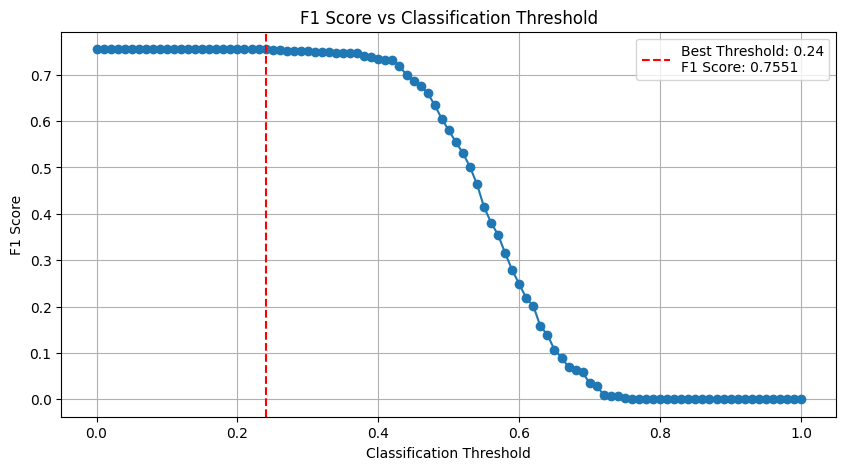

In [105]:
# count best threshold

thresholds = np.linspace(0.0, 1.0, num=101)
f1_scores = []
for threshold in thresholds:
    binary_preds = (val_probs >= threshold).astype(int)
    score = f1_score(y_val, binary_preds)
    f1_scores.append(score)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best Threshold: {best_threshold:.2f}\nF1 Score: {best_f1:.4f}')
plt.title('F1 Score vs Classification Threshold')
plt.xlabel('Classification Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.grid()
plt.show()

In [106]:
# metrics with best threshold

binary_preds_best = (val_probs >= best_threshold).astype(int)
print(f"Classification Report (threshold={best_threshold:.2f}):")
print(classification_report(y_val, binary_preds_best, digits=4))
print(f"Confusion Matrix (threshold={best_threshold:.2f}):")
print(confusion_matrix(y_val, binary_preds_best))
print(f"F1 Score (threshold={best_threshold:.2f}): {f1_score(y_val, binary_preds_best):.4f}")
print(f"Average Precision Score (threshold={best_threshold:.2f}): {average_precision_score(y_val, val_probs):.4f}")

Classification Report (threshold=0.24):
              precision    recall  f1-score   support

           0     0.6667    0.0049    0.0097       411
           1     0.6071    0.9984    0.7551       633

    accuracy                         0.6073      1044
   macro avg     0.6369    0.5016    0.3824      1044
weighted avg     0.6306    0.6073    0.4616      1044

Confusion Matrix (threshold=0.24):
[[  2 409]
 [  1 632]]
F1 Score (threshold=0.24): 0.7551
Average Precision Score (threshold=0.24): 0.7420


C:\Users\User\AppData\Local\Temp\ipykernel_4328\4006446885.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=feature_importances.head(20), palette="viridis")


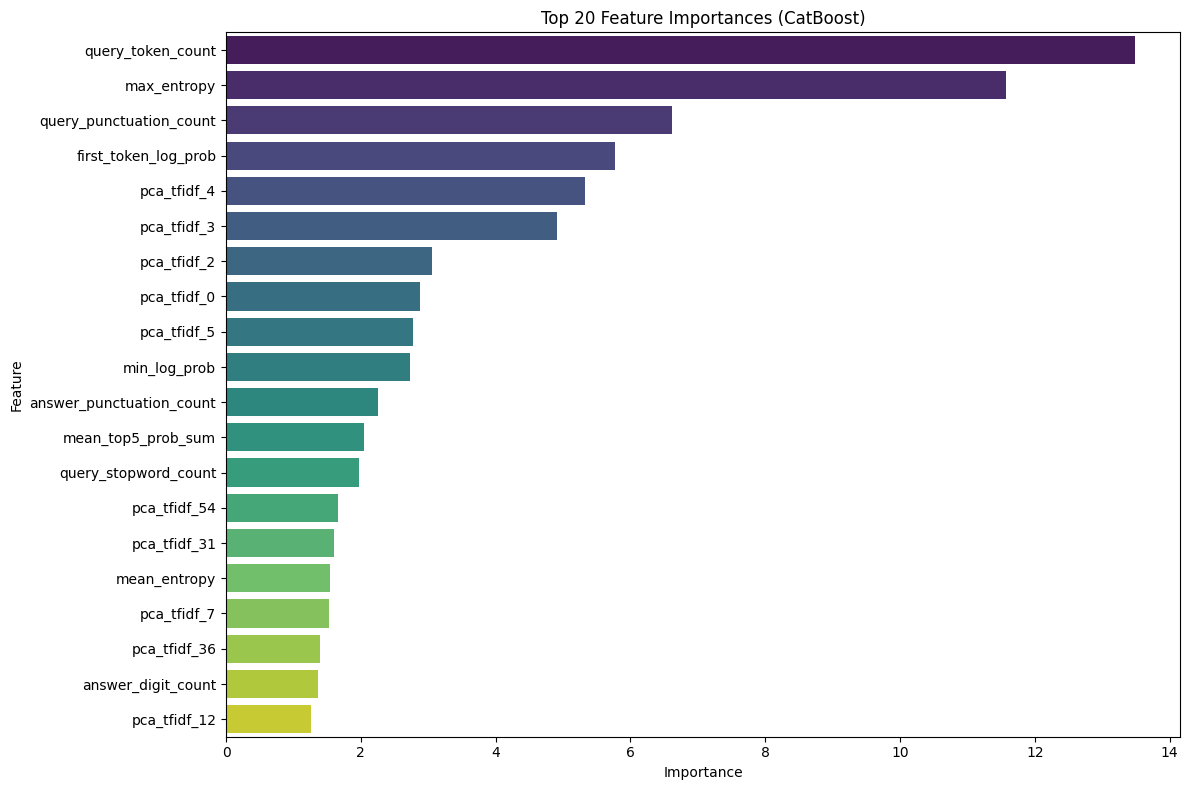

In [107]:
# feature importance
feature_importances = pd.DataFrame({
    "feature": selected_feature_names,
    "importance": catboost.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x="importance", y="feature", data=feature_importances.head(20), palette="viridis")
plt.title("Top 20 Feature Importances (CatBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [110]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=10000, random_state=42, class_weight='balanced')
logreg.fit(X_train, y_train)

val_preds_logreg = logreg.predict(X_val)
val_probs_logreg = logreg.predict_proba(X_val)[:, 1]

print("Logistic Regression Classification Report:")
print(classification_report(y_val, val_preds_logreg, digits=4))
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_val, val_preds_logreg))
print(f"Logistic Regression F1 Score: {f1_score(y_val, val_preds_logreg):.4f}")
print(f"Logistic Regression Average Precision Score: {average_precision_score(y_val, val_probs_logreg):.4f}")

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0     0.4572    0.8978    0.6059       411
           1     0.8228    0.3081    0.4483       633

    accuracy                         0.5402      1044
   macro avg     0.6400    0.6029    0.5271      1044
weighted avg     0.6789    0.5402    0.5103      1044

Logistic Regression Confusion Matrix:
[[369  42]
 [438 195]]
Logistic Regression F1 Score: 0.4483
Logistic Regression Average Precision Score: 0.7674
